In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/Mall_Customers.csv')

# Display the first few rows of the dataset
print("Dataset head:")
print(df.head())

# Display general information about the dataset
print("\nDataset info:")
df.info()

# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# Preprocess categorical features (e.g., 'Genre' column)
# Apply one-hot encoding to the 'Genre' column
df = pd.get_dummies(df, columns=['Genre'], drop_first=True)

print("\nDataset head after preprocessing (Genre one-hot encoded):")
print(df.head())

print("\nDataset info after preprocessing:")
df.info()

Dataset head:
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

Missing values per column:

## K-Means Clustering

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Select features for clustering
# We'll use 'Age', 'Annual Income (k$)', 'Spending Score (1-100)', and 'Genre_Male'
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Genre_Male']]

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled features (first 5 rows):")
print(X_scaled[:5])

Scaled features (first 5 rows):
[[-1.42456879 -1.73899919 -0.43480148  1.12815215]
 [-1.28103541 -1.73899919  1.19570407  1.12815215]
 [-1.3528021  -1.70082976 -1.71591298 -0.88640526]
 [-1.13750203 -1.70082976  1.04041783 -0.88640526]
 [-0.56336851 -1.66266033 -0.39597992 -0.88640526]]


### Determining Optimal Number of Clusters (Elbow Method)

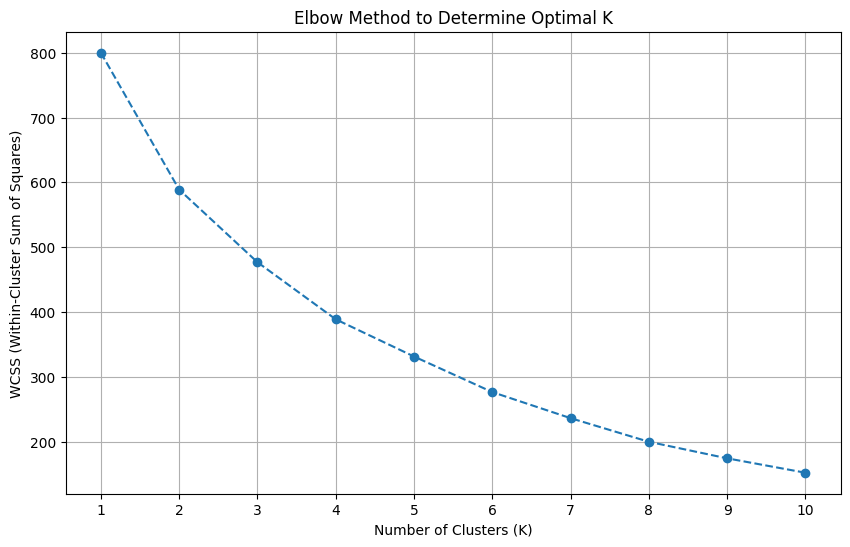

In [4]:
wcss = [] # Within-cluster sum of squares

# Try different numbers of clusters from 1 to 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method to Determine Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

Based on the elbow plot, we can choose an optimal number of clusters where the rate of decrease in WCSS (Within-Cluster Sum of Squares) sharply changes, forming an 'elbow'. For this dataset, a common choice would be around 4 or 5 clusters.

In [5]:
# Let's choose 5 as the optimal number of clusters (this can be adjusted based on the elbow plot)
n_clusters = 5

kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add the cluster labels to the original DataFrame
df['Cluster'] = clusters

print(f"\nAssigned {n_clusters} clusters. Cluster distribution:")
print(df['Cluster'].value_counts())

print("\nDataset head with cluster labels:")
print(df.head())


Assigned 5 clusters. Cluster distribution:
Cluster
3    54
2    43
0    39
4    35
1    29
Name: count, dtype: int64

Dataset head with cluster labels:
   CustomerID  Age  Annual Income (k$)  Spending Score (1-100)  Genre_Male  \
0           1   19                  15                      39        True   
1           2   21                  15                      81        True   
2           3   20                  16                       6       False   
3           4   23                  16                      77       False   
4           5   31                  17                      40       False   

   Cluster  
0        3  
1        3  
2        3  
3        3  
4        3  


### Visualizing the Clusters

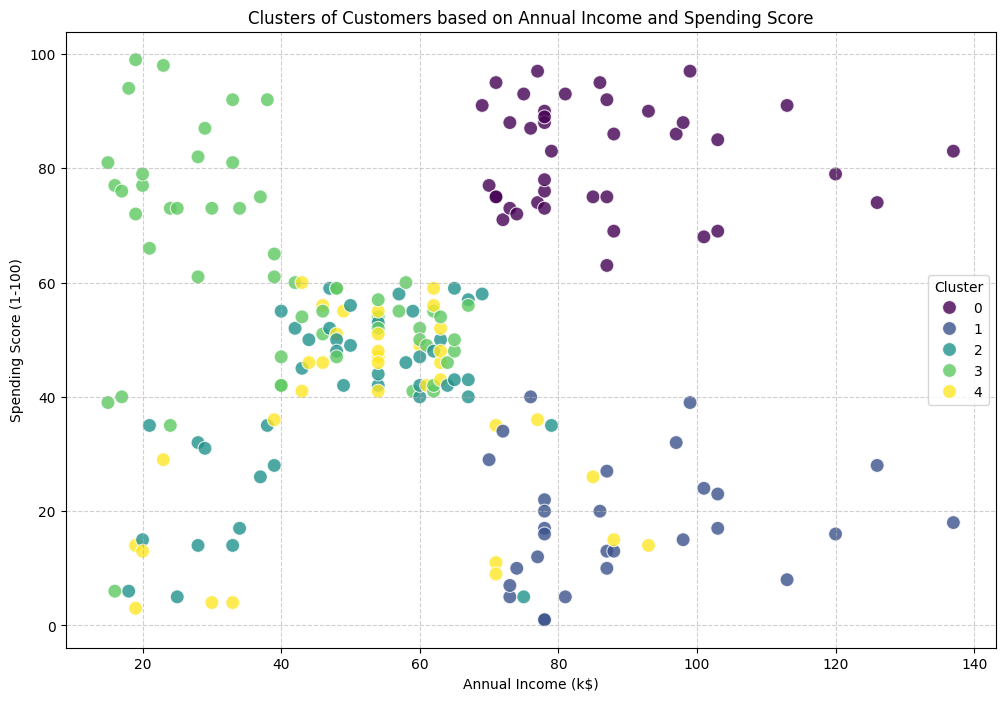

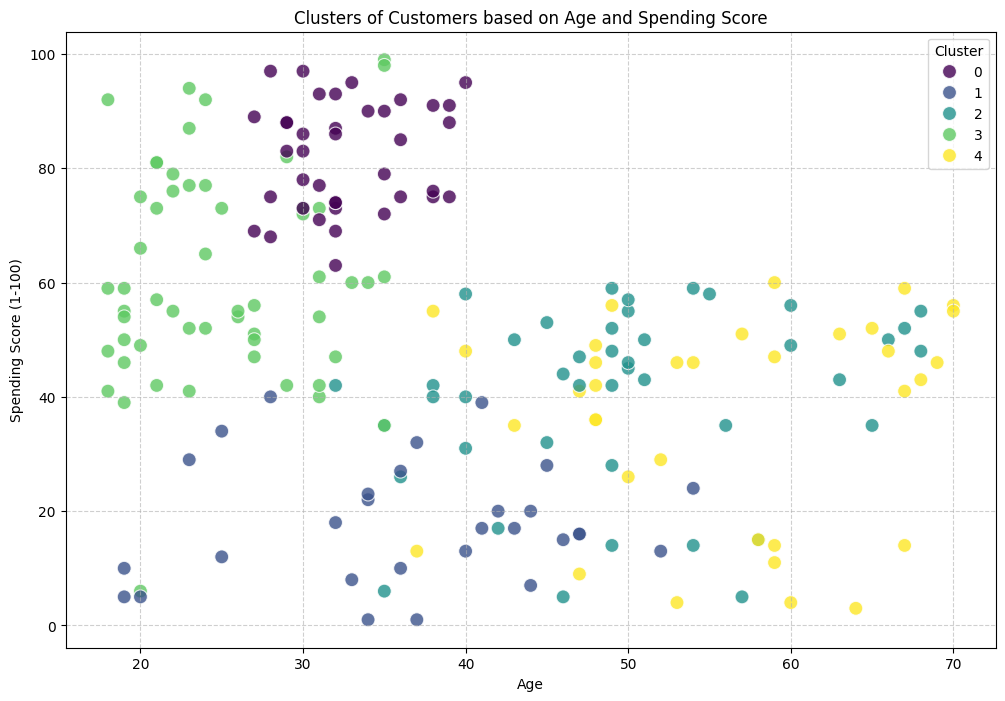

In [6]:
# Since we have more than 3 dimensions, we'll visualize using pairs of features.
# Let's visualize 'Annual Income (k$)' vs 'Spending Score (1-100)' colored by cluster.
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='viridis',
    data=df,
    s=100,  # size of points
    alpha=0.8 # transparency
)
plt.title('Clusters of Customers based on Annual Income and Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Cluster')
plt.show()

# You can also visualize other pairs, for example, 'Age' vs 'Spending Score (1-100)'
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='Age',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='viridis',
    data=df,
    s=100,  # size of points
    alpha=0.8 # transparency
)
plt.title('Clusters of Customers based on Age and Spending Score')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Cluster')
plt.show()

In [7]:
# Analyze cluster characteristics
print("\nCluster characteristics (mean values for each feature):")
print(df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Genre_Male']].mean())



Cluster characteristics (mean values for each feature):
               Age  Annual Income (k$)  Spending Score (1-100)  Genre_Male
Cluster                                                                   
0        32.692308           86.538462               82.128205    0.461538
1        36.482759           89.517241               18.000000    0.448276
2        49.813953           49.232558               40.069767    0.000000
3        24.907407           39.722222               61.203704    0.407407
4        55.714286           53.685714               36.771429    1.000000
